# Student Dropout Prediction Notebook

This notebook reproduces your script as a step-by-step workflow:
1. Load libraries and dataset
2. Clean and preprocess target labels
3. Visualize correlations and class-wise distributions
4. Train and evaluate a Random Forest classifier
5. Compare split seeds and cross-validation results
6. Plot normalized confusion matrix
7. Retrain using only 1% of training data

In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Question 1

In [25]:
# Load the UCI dropout dataset (semicolon-separated)
df = pd.read_csv("data.csv", sep=";")

print("Dataset shape:", df.shape)
display(df.head())

print("nb de dropout : " + str(df[df['Target'] == "Dropout"].shape))

print("nb de enrolled : " +str(df[df['Target'] == "Enrolled"].shape))

print("nb de graduate : " + str(df[df['Target'] == "Graduate"].shape))

# Map Target to binary: 0=Dropout, 1=Enrolled/Graduate
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 1}
df['Target'] = df['Target'].map(target_mapping)

# Drop potential NaNs after mapping
df = df.dropna(subset=['Target'])

X = df.drop('Target', axis=1)
y = df['Target']

print(f'Dataset shape: {df.shape}')
print(y.value_counts().rename(index={0: 'Dropout (0)', 1: 'Success (1)'}))

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


nb de dropout : (1421, 37)
nb de enrolled : (794, 37)
nb de graduate : (2209, 37)
Dataset shape: (4424, 37)
Target
Success (1)    3003
Dropout (0)    1421
Name: count, dtype: int64


Question 2

/Users/erwannhequet/Library/Python/3.9/lib/python/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/erwannhequet/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


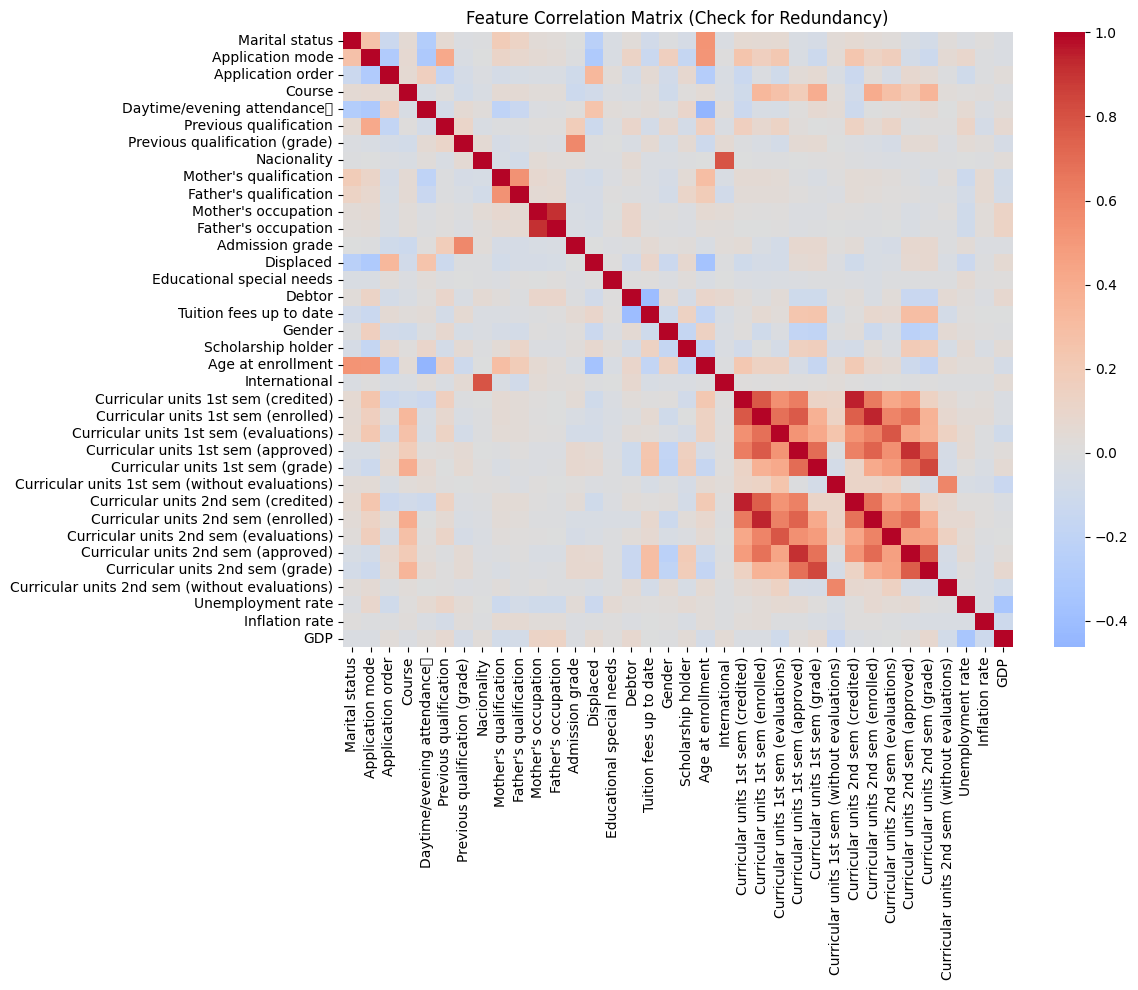

In [ ]:
# Correlation matrix to detect redundant features
plt.figure(figsize=(12, 10))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix (Check for Redundancy)')
plt.tight_layout()
plt.show()

/var/folders/nc/913x4t155x1gnc95b8q174xc0000gn/T/ipykernel_15543/4227227176.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/erwannhequet/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


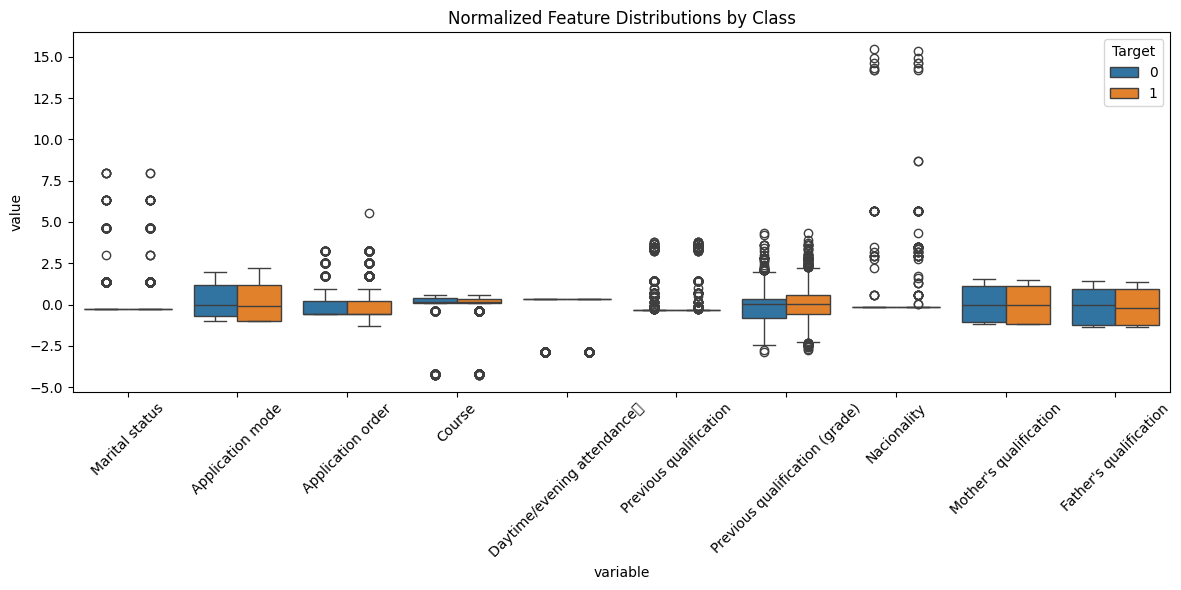

In [33]:
# Normalize features for distribution visualization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled['Target'] = y.reset_index(drop=True)

# Plot a subset of features to avoid visual clutter
features_to_plot = X.columns[:10]
X_melted = pd.melt(X_scaled, id_vars=['Target'], value_vars=features_to_plot)

plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', hue='Target', data=X_melted)
plt.title('Normalized Feature Distributions by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X_scaled = X_scaled.drop('Target', axis=1)

## 2) Train/Test Split and Baseline Classifier